# Bank Customer Churn
### Introduction
This project develops a machine learning solution to predict customer churn for banks, helping financial institutions retain clients and reduce acquisition costs. Using a comprehensive dataset of customer profiles, account details, and service interactions, we build predictive models to identify at-risk customers before they leave.

### Required Libraries

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from pylab import rcParams
from pathlib import Path

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

### Load Dataset

In [5]:
# Create directory for images 
Path("img").mkdir(parents=True, exist_ok=True)

# Set default figure size
rcParams['figure.figsize'] = (4, 4)

# Tell pandas how to display floats
pd.options.display.float_format = "{:,.2f}".format

In [6]:
path = 'Downloads/Customer-Churn-Records.csv'

In [7]:
df = pd.read_csv(path, lineterminator='\n')

### Initial Exploration

In [9]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned\r
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0,0,5,GOLD,425


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [11]:
df.shape

(10000, 18)

In [12]:
df.nunique()

RowNumber             10000
CustomerId            10000
Surname                2932
CreditScore             460
Geography                 3
Gender                    2
Age                      70
Tenure                   11
Balance                6382
NumOfProducts             4
HasCrCard                 2
IsActiveMember            2
EstimatedSalary        9999
Exited                    2
Complain                  2
Satisfaction Score        5
Card Type                 4
Point Earned\r          785
dtype: int64

In [13]:
df = df.rename(columns={'Point Earned\r': 'Point Earned'})

In [14]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"5,000.50","15,690,940.57",650.53,38.92,5.01,"76,485.89",1.53,0.71,0.52,"100,090.24",0.20,0.20,3.01,606.52
std,"2,886.90","71,936.19",96.65,10.49,2.89,"62,397.41",0.58,0.46,0.50,"57,510.49",0.40,0.40,1.41,225.92
min,1.00,"15,565,701.00",350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00,0.00,1.00,119.00
25%,"2,500.75","15,628,528.25",584.00,32.00,3.00,0.00,1.00,0.00,0.00,"51,002.11",0.00,0.00,2.00,410.00
50%,"5,000.50","15,690,738.00",652.00,37.00,5.00,"97,198.54",1.00,1.00,1.00,"100,193.91",0.00,0.00,3.00,605.00
75%,"7,500.25","15,753,233.75",718.00,44.00,7.00,"127,644.24",2.00,1.00,1.00,"149,388.25",0.00,0.00,4.00,801.00
max,"10,000.00","15,815,690.00",850.00,92.00,10.00,"250,898.09",4.00,1.00,1.00,"199,992.48",1.00,1.00,5.00,"1,000.00"


In [15]:
df.dtypes

RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

In [16]:
# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6));

<Figure size 1200x600 with 0 Axes>

### Visualizations

In [18]:
#Removing Irrelevant Columns
irrelevant_columns = ['RowNumber', 'CustomerId', 'Surname']
data = df.drop(columns=irrelevant_columns, errors='ignore')

In [19]:
numerical_cols = []
categorical_cols = []

for col in data.columns:
    if data[col].dtype in ['int64', 'float64']:
        unique_values = data[col].nunique()
        if unique_values <=5:
            categorical_cols.append(col)
        else:
            numerical_cols.append(col)
    else:
        categorical_cols.append(col)

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Point Earned']
Categorical Columns: ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type']


<Axes: >

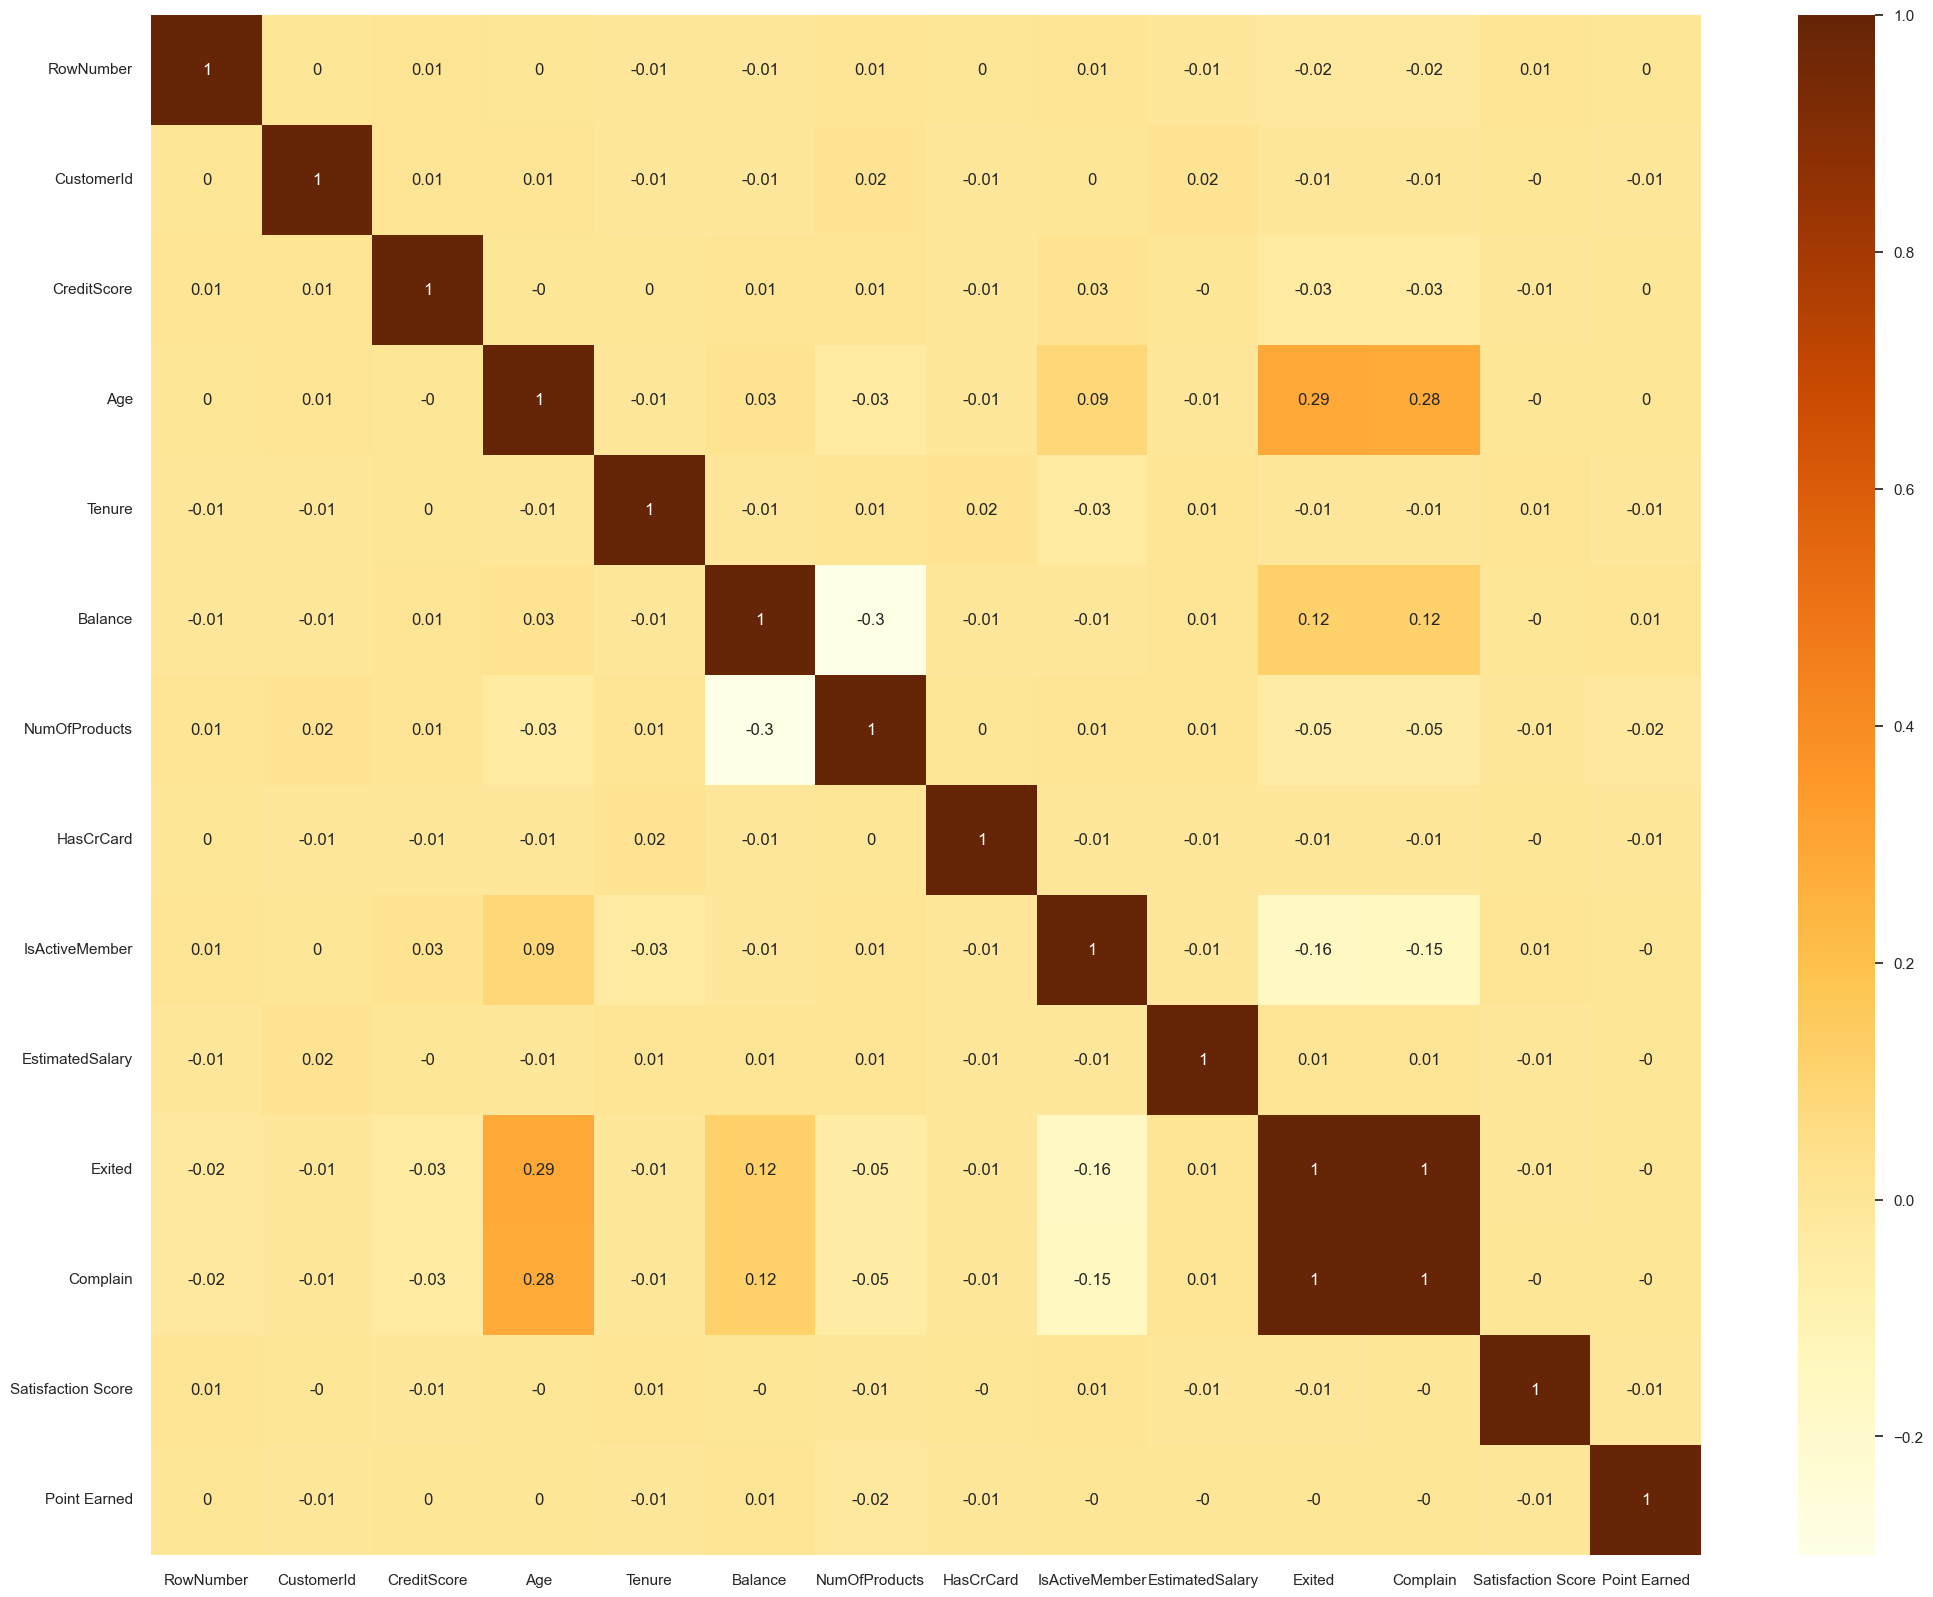

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr().round(2)
plt.figure(figsize = (25,20))
sns.heatmap(corr, annot = True, cmap = 'YlOrBr')

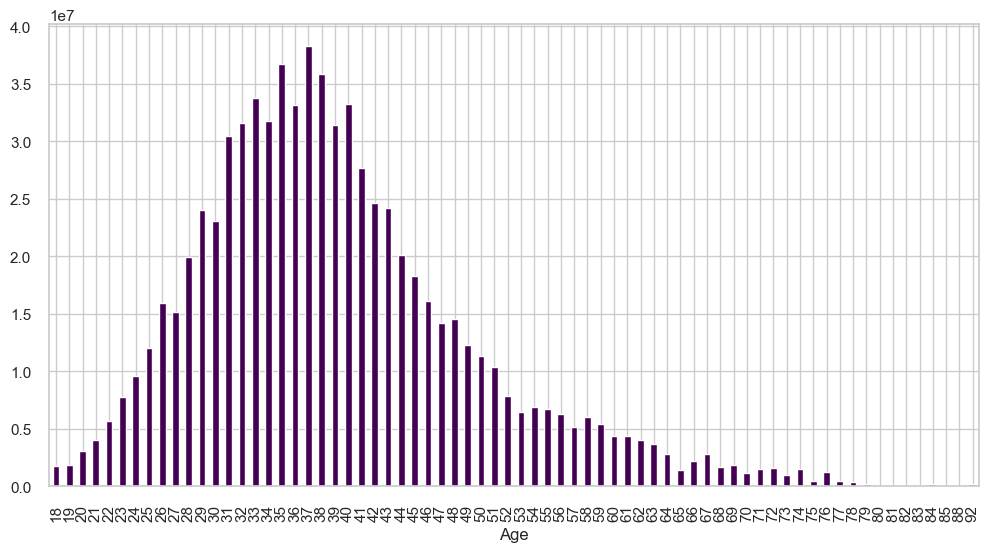

In [21]:
geo_mele = df.groupby('Age')['Balance'].sum().sort_index(ascending=True)
geo_mele.plot(kind='bar', figsize = (12,6), colormap='viridis');

<Axes: title={'center': 'Variable Card Type'}, xlabel='Card Type', ylabel='count'>

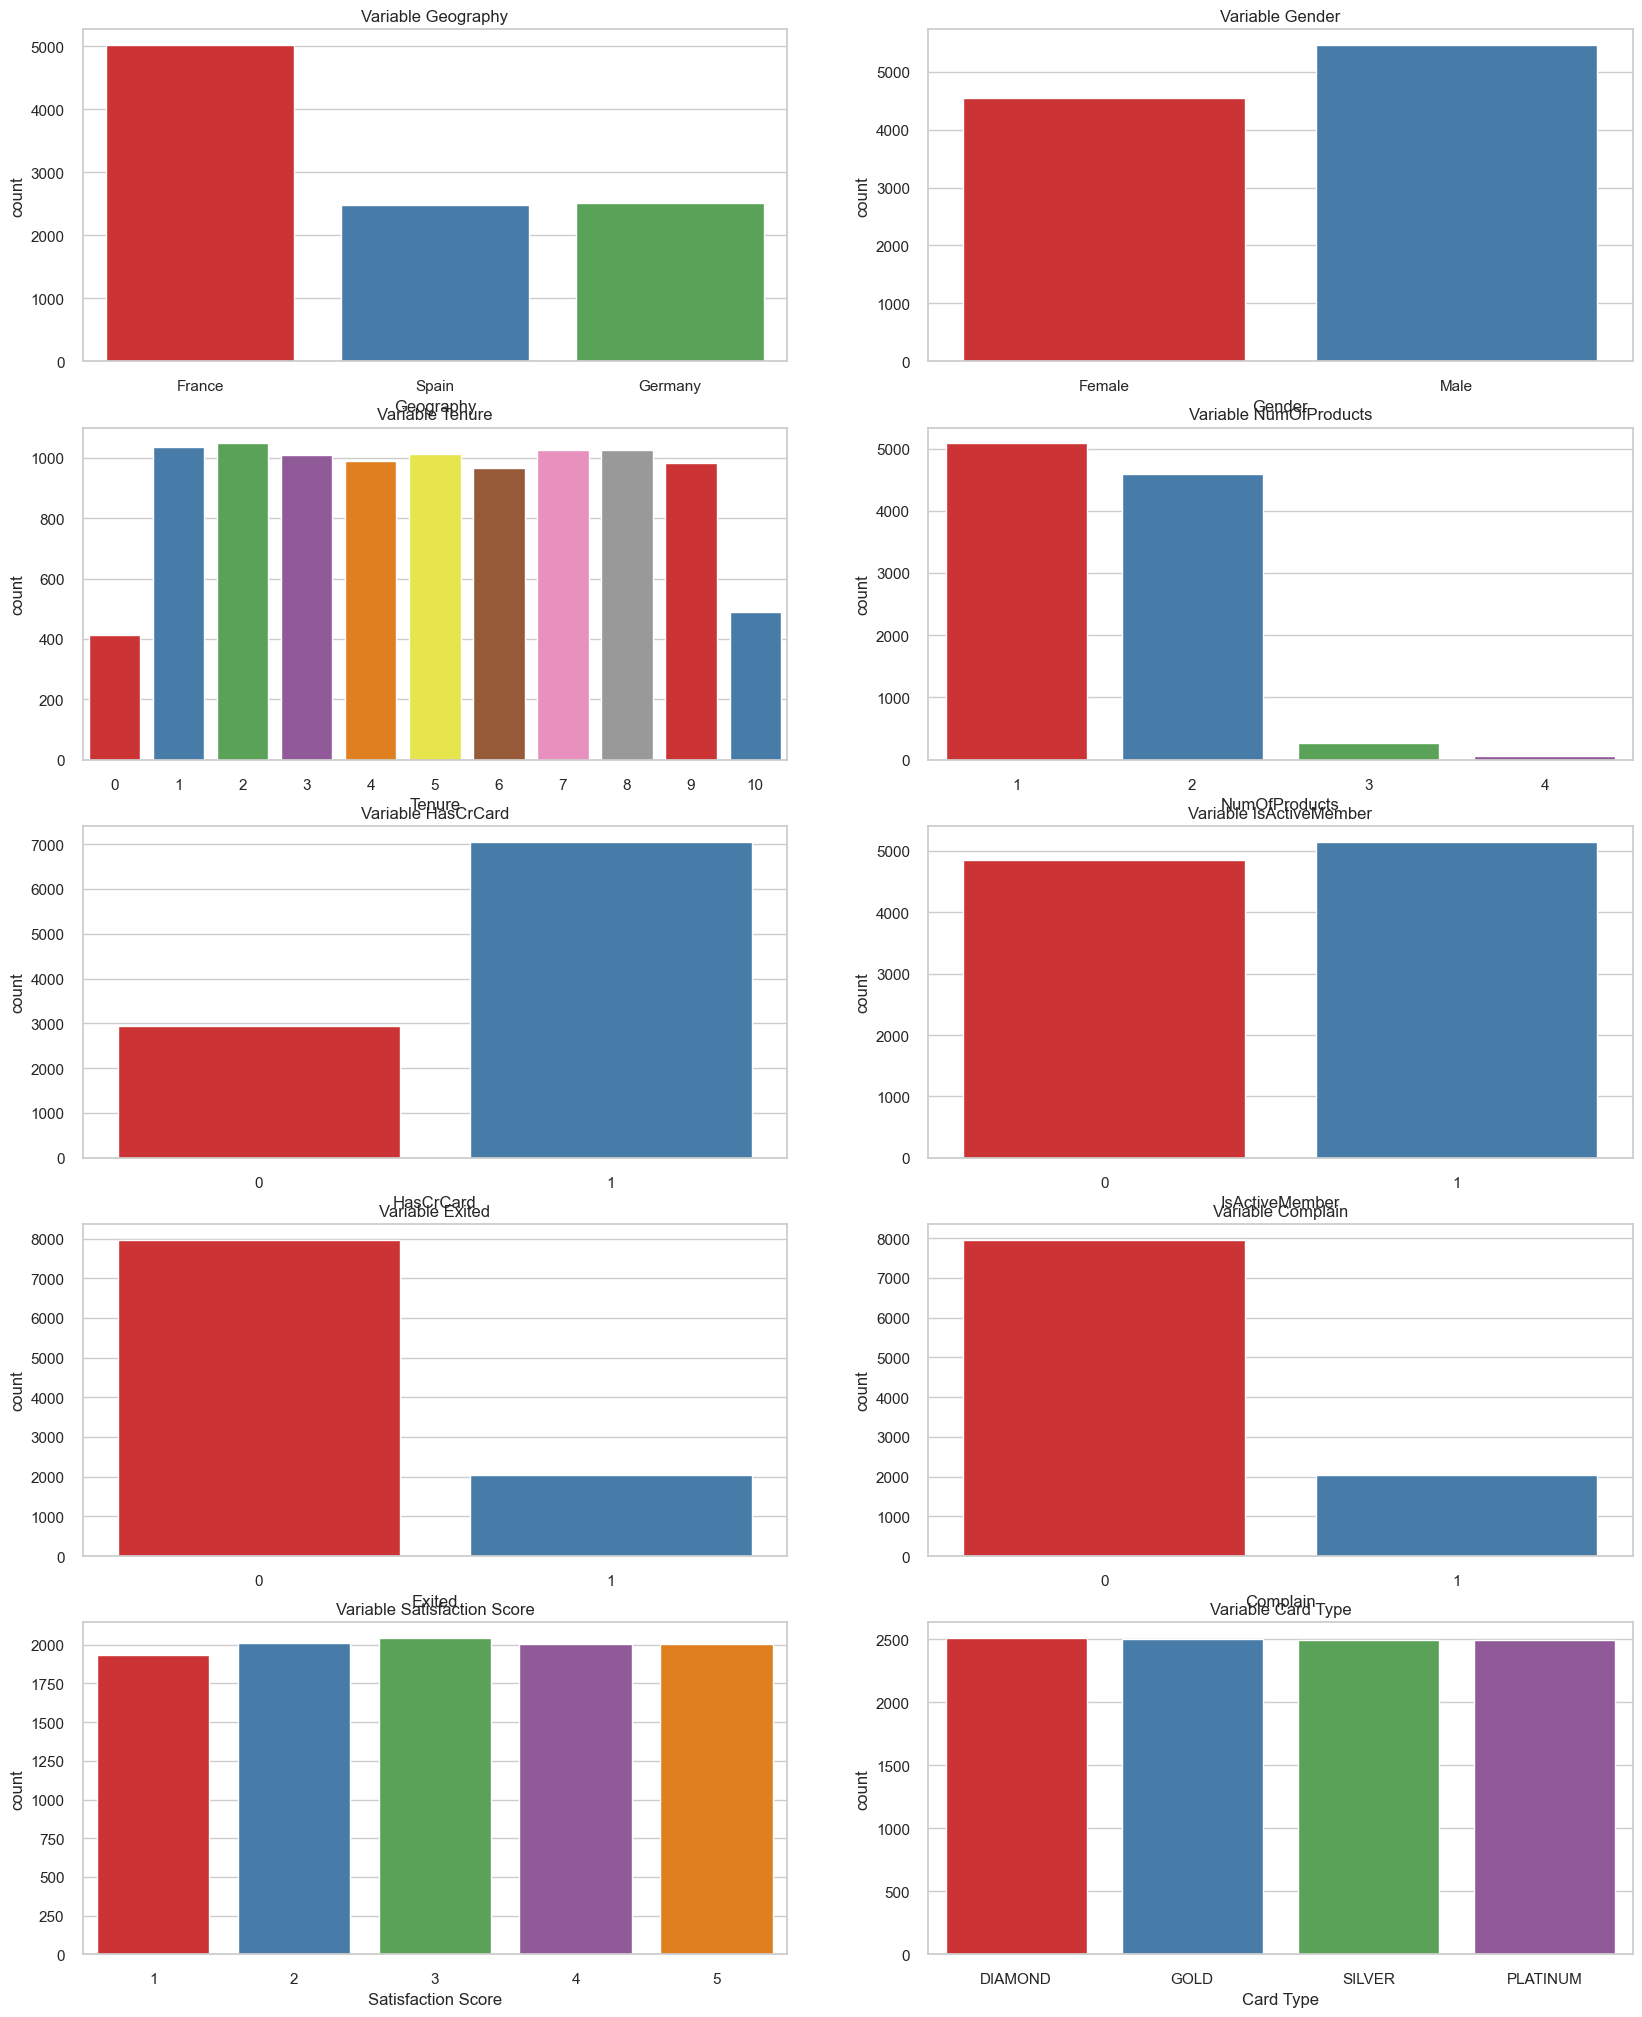

In [22]:
plt.figure(figsize = (20, 25))

plt.subplot(5, 2, 1)
plt.gca().set_title('Variable Geography')
sns.countplot(x = 'Geography', hue='Geography', palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 2)
plt.gca().set_title('Variable Gender')
sns.countplot(x = 'Gender', hue='Gender',palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 3)
plt.gca().set_title('Variable Tenure')
sns.countplot(x = 'Tenure', hue='Tenure',palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 4)
plt.gca().set_title('Variable NumOfProducts')
sns.countplot(x = 'NumOfProducts', hue='NumOfProducts', palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 5)
plt.gca().set_title('Variable HasCrCard')
sns.countplot(x = 'HasCrCard', hue='HasCrCard', palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 6)
plt.gca().set_title('Variable IsActiveMember')
sns.countplot(x = 'IsActiveMember', hue='IsActiveMember', palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 7)
plt.gca().set_title('Variable Exited')
sns.countplot(x = 'Exited', hue='Exited', palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 8)
plt.gca().set_title('Variable Complain')
sns.countplot(x = 'Complain', hue='Complain', palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 9)
plt.gca().set_title('Variable Satisfaction Score')
sns.countplot(x = 'Satisfaction Score', hue='Satisfaction Score', palette = 'Set1', data = df, legend=False)

plt.subplot(5, 2, 10)
plt.gca().set_title('Variable Card Type')
sns.countplot(x = 'Card Type', hue='Card Type', palette = 'Set1', data = df, legend=False)

<Axes: xlabel='Point Earned', ylabel='Count'>

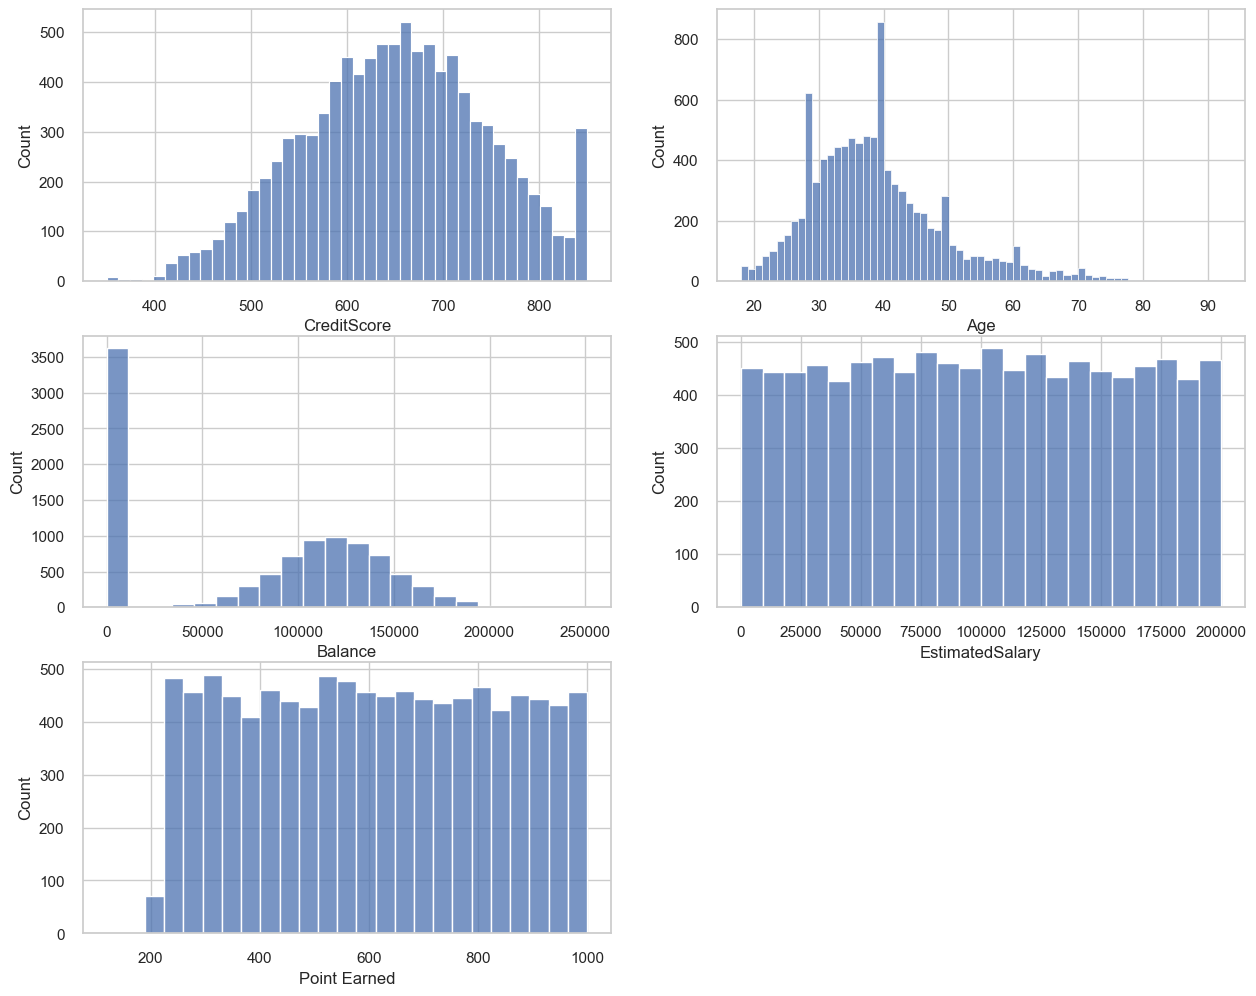

In [23]:
plt.figure(figsize = (15, 12))

plt.subplot(3, 2, 1)
sns.histplot(x = df['CreditScore'], kde = False)

plt.subplot(3, 2, 2)
sns.histplot(x = df['Age'], kde = False)

plt.subplot(3, 2, 3)
sns.histplot(x = df['Balance'], kde = False)

plt.subplot(3, 2, 4)
sns.histplot(x = df['EstimatedSalary'], kde = False)

plt.subplot(3, 2, 5)
sns.histplot(x = df['Point Earned'], kde = False)

<Axes: title={'center': 'Boxplot Point Earned'}, xlabel='Point Earned'>

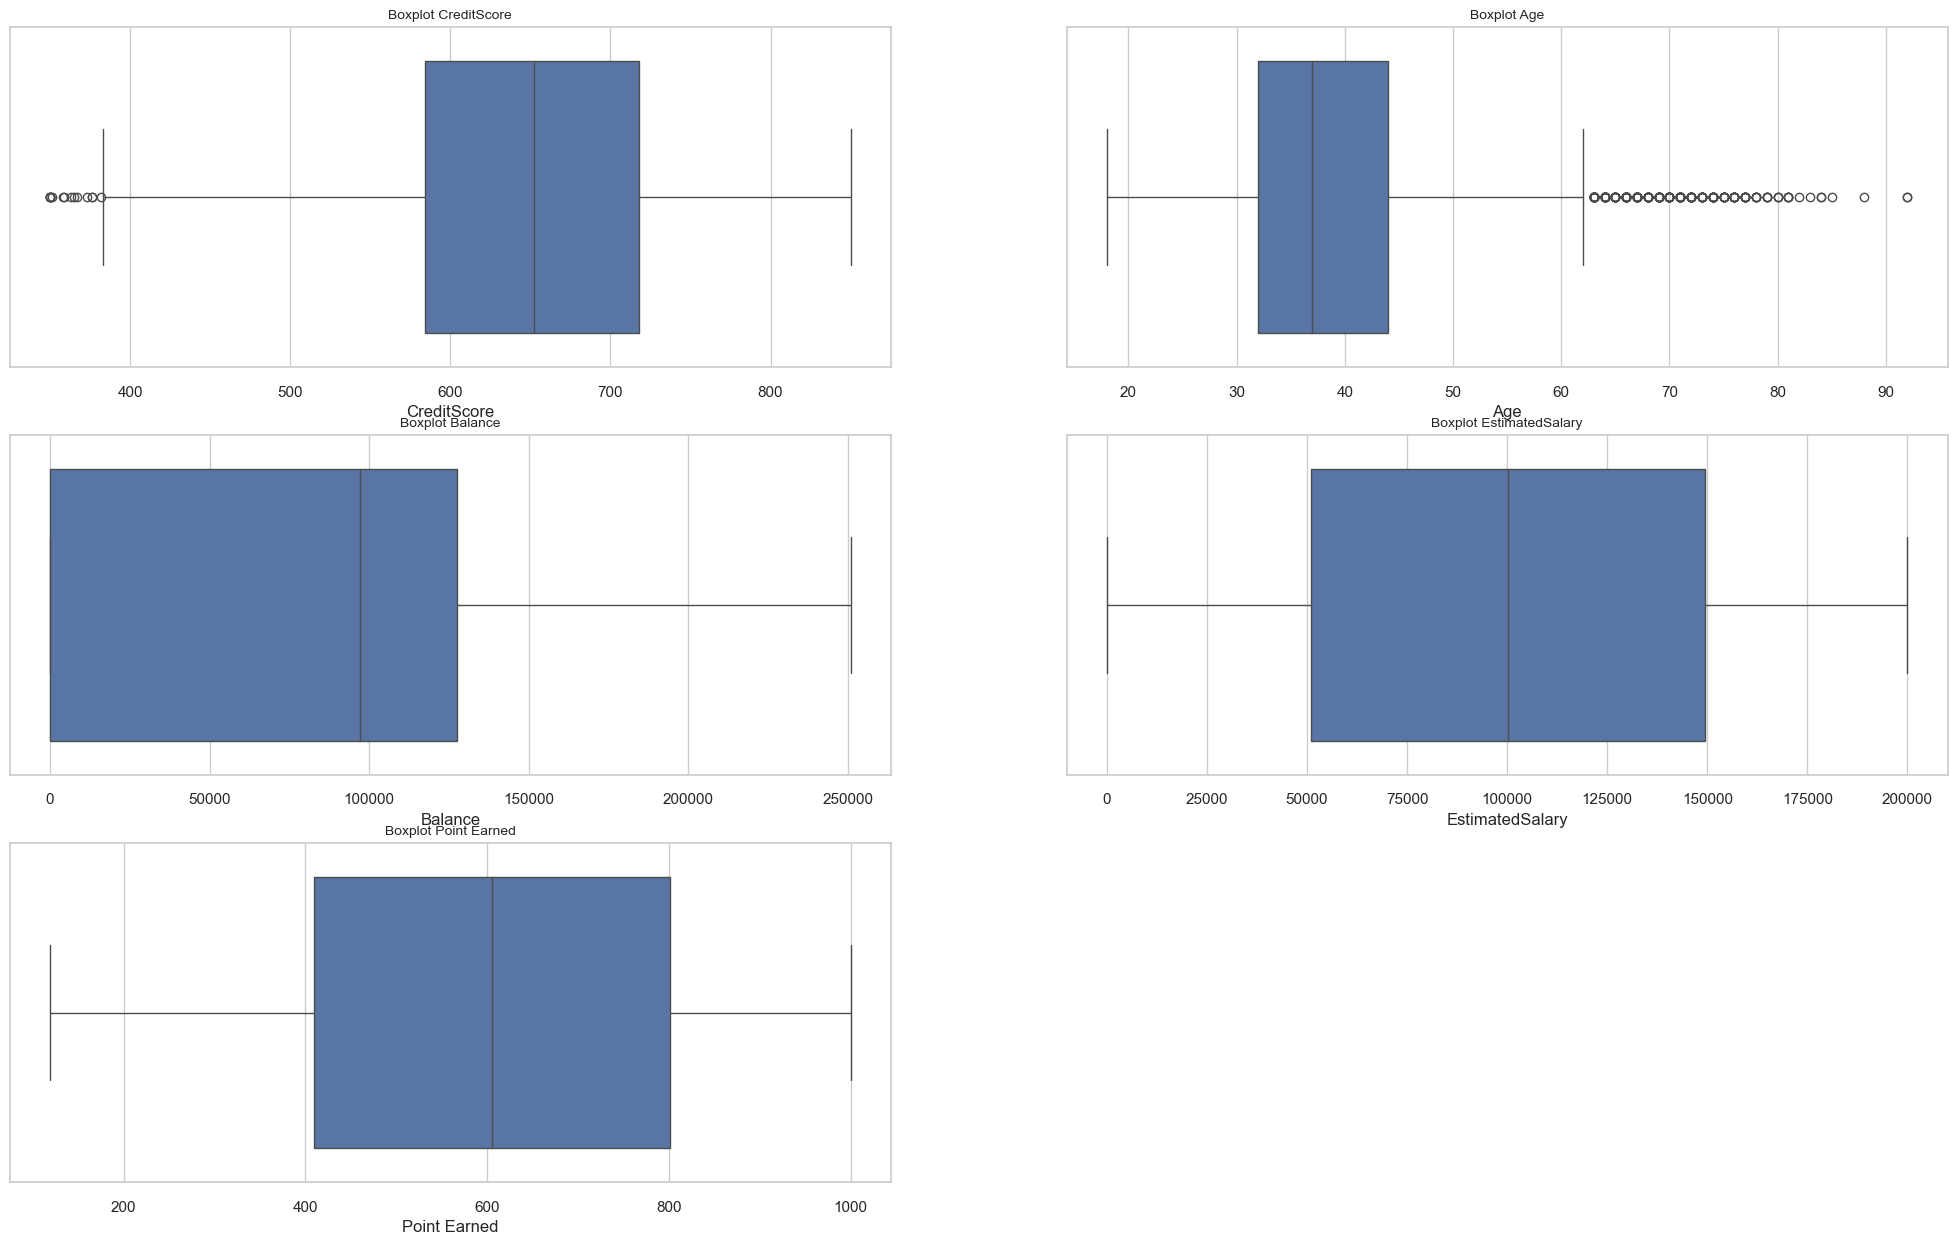

In [24]:
plt.figure(figsize = (25, 15))

plt.subplot(3,2,1)
plt.title("Boxplot CreditScore", fontdict = {'fontsize': 10})
sns.boxplot(x=df["CreditScore"])

plt.subplot(3,2,2)
plt.title("Boxplot Age", fontdict = {'fontsize': 10})
sns.boxplot(x=df["Age"])

plt.subplot(3,2,3)
plt.title("Boxplot Balance", fontdict = {'fontsize': 10})
sns.boxplot(x=df["Balance"])

plt.subplot(3,2,4)
plt.title("Boxplot EstimatedSalary", fontdict = {'fontsize': 10})
sns.boxplot(x=df["EstimatedSalary"])

plt.subplot(3,2,5)
plt.title("Boxplot Point Earned", fontdict = {'fontsize': 10})
sns.boxplot(x=df["Point Earned"])

Looking at the boxplots of our continuous variables we can see that we have few outliers, for now we will leave them

<Axes: xlabel='Exited', ylabel='Point Earned'>

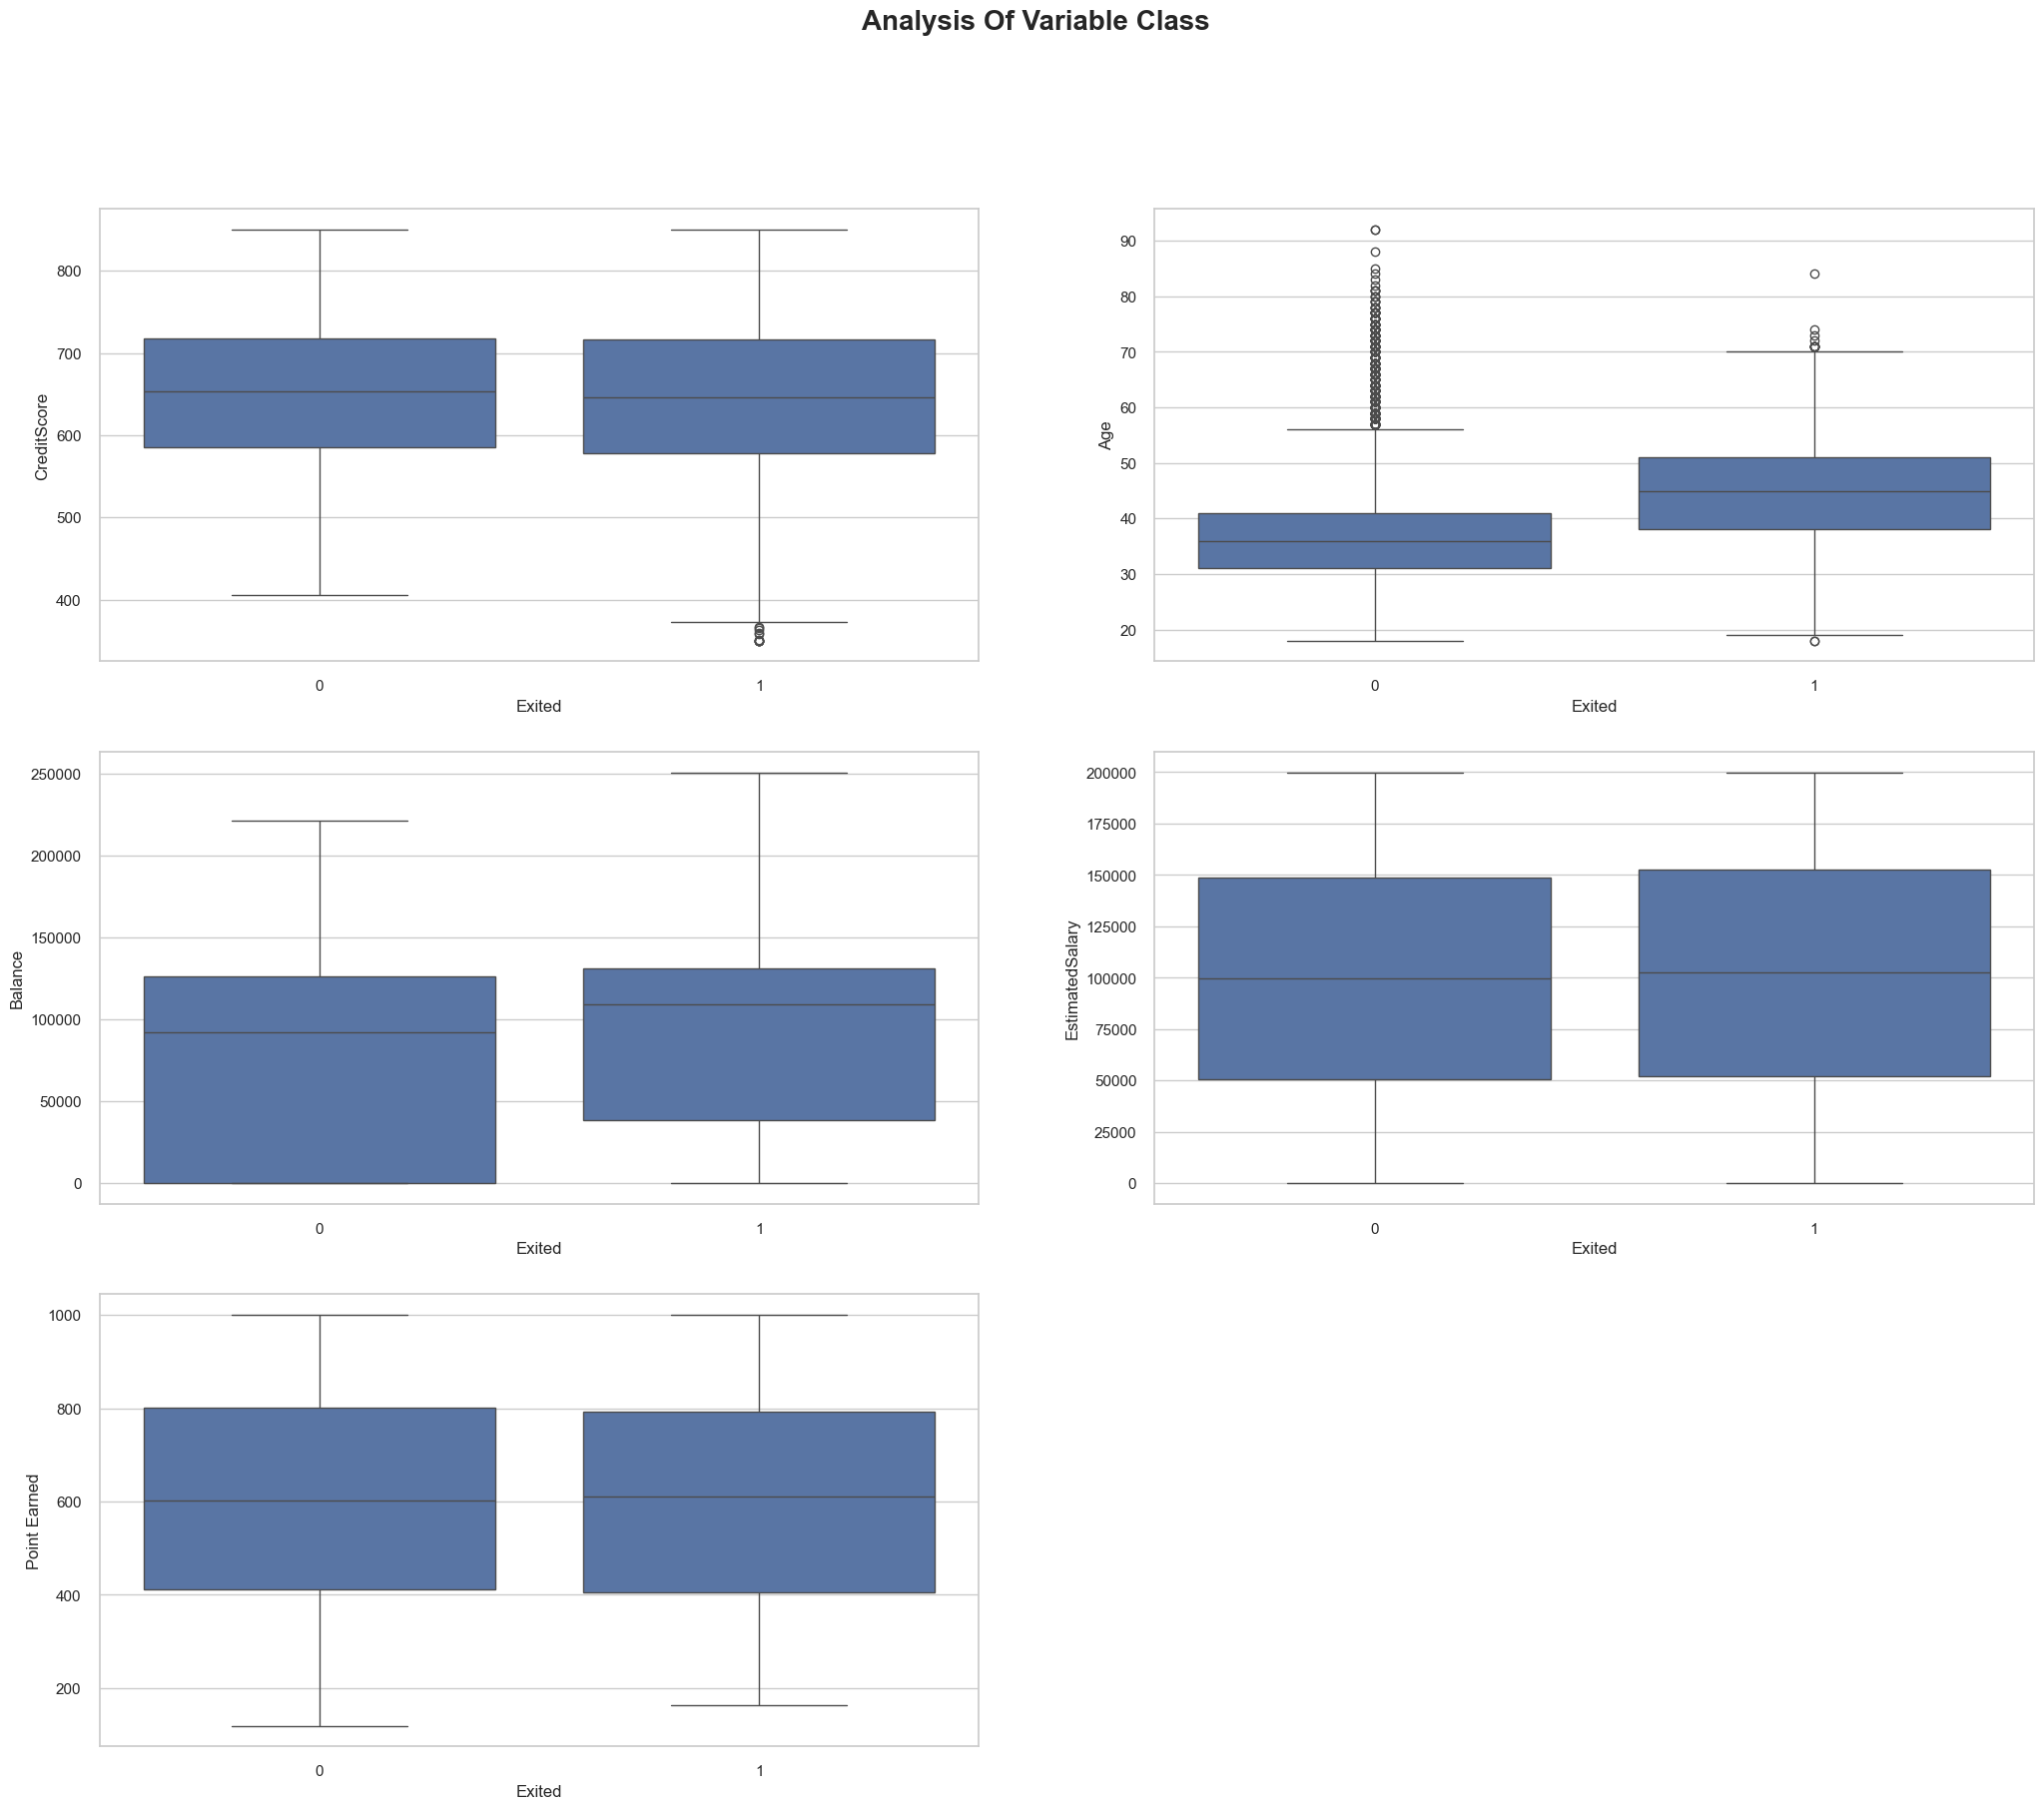

In [26]:
plt.figure(figsize = (25, 20))
plt.suptitle("Analysis Of Variable Class",fontweight="bold", fontsize=20)

plt.subplot(3,2,1)
sns.boxplot(x="Exited", y="CreditScore", data=df)

plt.subplot(3,2,2)
sns.boxplot(x="Exited", y="Age", data=df)

plt.subplot(3,2,3)
sns.boxplot(x="Exited", y="Balance", data=df)

plt.subplot(3,2,4)
sns.boxplot(x="Exited", y="EstimatedSalary", data=df)

plt.subplot(3,2,5)
sns.boxplot(x="Exited", y="Point Earned", data=df)

### Model Building

In [28]:
hot = pd.get_dummies(df[['Geography', 'Gender', 'Card Type']])

df = pd.concat([df, hot], axis = 1)
df = df.drop(['Geography', 'Gender', 'Card Type'], axis = 1)

In [29]:
#Separating into features variables and target variable
X = df.drop('Exited', axis = 1).select_dtypes(include=['int64', 'float64'])
X = X.values
y = df['Exited']

In [30]:
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

X_train,X_test, y_train, y_test = train_test_split(X_standard, y, test_size = 0.3, random_state = 0)

ros = RandomOverSampler(random_state=0)
X_train, y_train = ros.fit_resample(X_train, y_train)

0.9986666666666667

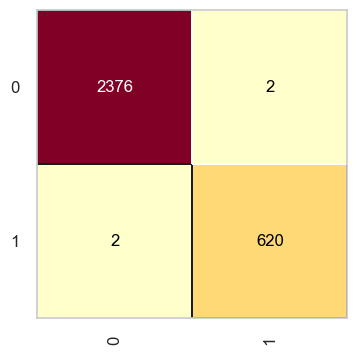

In [31]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)
previsoes = naive_bayes.predict(X_test)

cm = ConfusionMatrix(naive_bayes)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

In [32]:
classification_naive_gaussian = (classification_report(y_test, previsoes))
print(classification_naive_gaussian)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2378
           1       1.00      1.00      1.00       622

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

